# nb3_validation_and_plots
Validation, with the plots — backs sections 6.4 and 7. Produces the per-family AUC figures and the association-vs-therapeutic orthogonality scatter.**Assertion-first.** Every documented value is checked against live data and reported `PASS` or `STALE`. A stale document fails loudly here instead of rotting silently.Code env: `primekg_kg`.

In [7]:
import dataiku, numpy as np, pandas as pd, math
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from IPython.display import Image, display
FAIL=[]
def check(name,doc,live,tol=0.0,fmt="{:,}"):
    ok=(abs(doc-live)<=tol) if isinstance(doc,(int,float)) else (doc==live)
    if not ok: FAIL.append((name,doc,live))
    print(f"CHK|{'PASS ' if ok else 'STALE'}|{name:48s} doc={fmt.format(doc):>13s} live={fmt.format(live):>13s}")

## 7.1  the headline: macro per-disease AUC

In [8]:
va=dataiku.Dataset("validation_auc_by_disease").get_dataframe()
print(f"AUC|diseases={len(va)}|macro={va.auc_disease.mean():.4f}|"
      f"pos>=10 macro={va[va.n_pos>=10].auc_disease.mean():.4f}")
check("10.1 macro per-disease AUC",0.8230,round(float(va.auc_disease.mean()),4),tol=0.0006,fmt="{:.4f}")
check("10.1 validation diseases",670,len(va))


AUC|diseases=670|macro=0.8230|pos>=10 macro=0.8351
CHK|PASS |10.1 macro per-disease AUC                       doc=       0.8230 live=       0.8230
CHK|PASS |10.1 validation diseases                         doc=          670 live=          670


## 7.3  per-family validation, and the plot that replaces a 45-number table

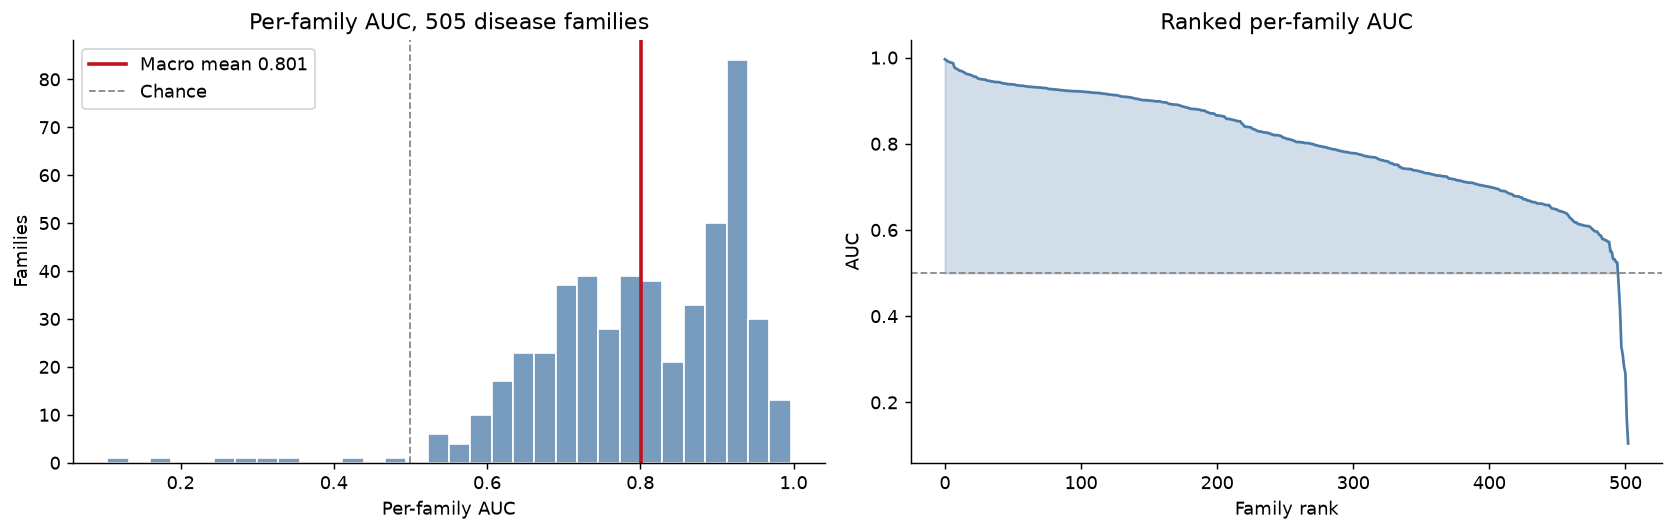

CHK|PASS |7.3 per-family macro AUC                         doc=       0.8009 live=       0.8009
CHK|PASS |7.3 families                                     doc=          505 live=          505


In [9]:
fa = dataiku.Dataset("family_auc_by_family").get_dataframe()
col = next(c for c in fa.columns if "auc" in c.lower())

macro_auc = fa[col].mean()
srt = fa[[col]].dropna().sort_values(col, ascending=False).reset_index(drop=True)
srt["family_rank"] = srt.index

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(
    data=fa, x=col, bins=32,
    color="#4a7ba7", edgecolor="white",
    ax=ax[0],
)
ax[0].axvline(macro_auc, color="#c1121f", lw=2,
              label=f"Macro mean {macro_auc:.3f}")
ax[0].axvline(0.5, color="#888", ls="--", lw=1, label="Chance")
ax[0].set(
    xlabel="Per-family AUC",
    ylabel="Families",
    title=f"Per-family AUC, {len(fa)} disease families",
)
ax[0].legend()

sns.lineplot(
    data=srt, x="family_rank", y=col,
    color="#4a7ba7", linewidth=1.5,
    ax=ax[1],
)
ax[1].fill_between(
    srt["family_rank"], 0.5, srt[col],
    where=srt[col] >= 0.5,
    color="#4a7ba7", alpha=0.25,
)
ax[1].axhline(0.5, color="#888", ls="--", lw=1)
ax[1].set(
    xlabel="Family rank",
    ylabel="AUC",
    title="Ranked per-family AUC",
)

sns.despine(fig=fig)
fig.tight_layout()

plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=130, bbox_inches="tight")
plot_buffer.seek(0)

display(Image(data=plot_buffer.getvalue()))
plt.close(fig)

check("7.3 per-family macro AUC", 0.8009, round(float(macro_auc), 4),
      tol=0.0006, fmt="{:.4f}")
check("7.3 families", 505, len(fa))

## 7.4  THE key plot: association AUC does not predict therapeutic relevance

ORTH|n=130|pearson=+0.0020|R2=0.0000|spearman=-0.0062|slope=+0.0034|t=+0.02
ORTH|well-powered n=42|pearson=-0.0518
CHK|PASS |7.4 orthogonality pearson r                      doc=       +0.002 live=       +0.002
CHK|PASS |7.4 orthogonality R2                             doc=       0.0000 live=       0.0000


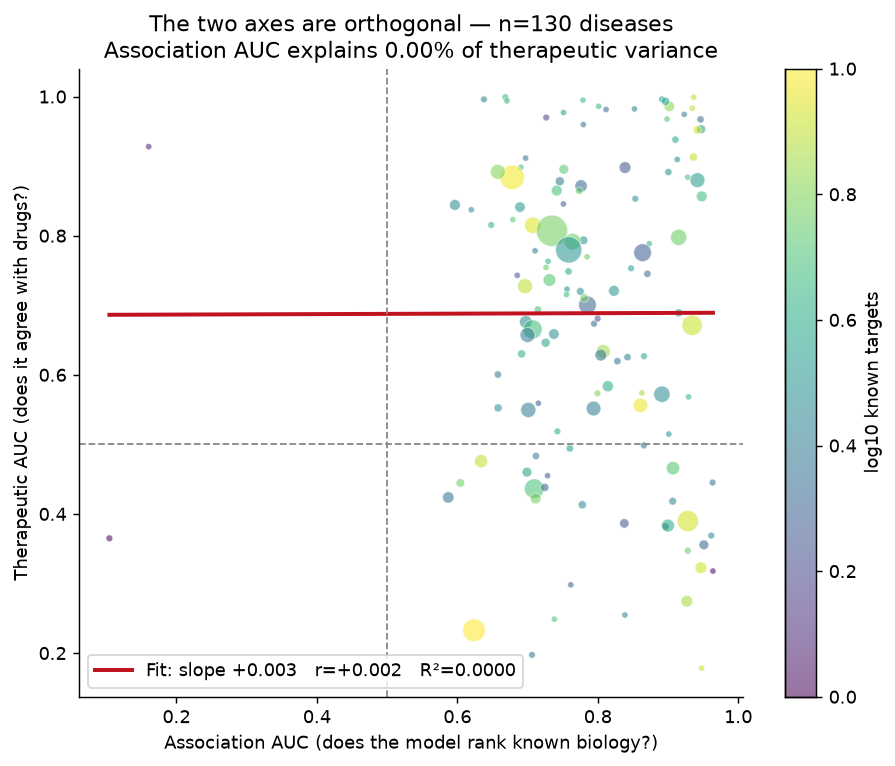

In [10]:
db = dataiku.Dataset("drug_target_benchmark").get_dataframe()

j = (
    va.merge(db, on="disease_index", suffixes=("", "_d"))
      [["disease_index", "auc_disease", "auc_drug_targets",
        "n_validated_targets", "n_pos"]]
      .dropna(subset=["auc_disease", "auc_drug_targets"])
)

x = j["auc_disease"].to_numpy()
y = j["auc_drug_targets"].to_numpy()
n = len(j)

r = np.corrcoef(x, y)[0, 1]
slope, inter = np.polyfit(x, y, 1)
rs = pd.Series(x).rank().corr(pd.Series(y).rank())
t = r * math.sqrt((n - 2) / max(1e-12, 1 - r**2))

wp = j[j["n_validated_targets"] >= 10]
rw = np.corrcoef(wp["auc_disease"], wp["auc_drug_targets"])[0, 1] if len(wp) > 5 else np.nan

print(
    f"ORTH|n={n}|pearson={r:+.4f}|R2={r*r:.4f}|"
    f"spearman={rs:+.4f}|slope={slope:+.4f}|t={t:+.2f}"
)
print(f"ORTH|well-powered n={len(wp)}|pearson={rw:+.4f}")

check("7.4 orthogonality pearson r", 0.002, round(float(r), 3), tol=0.004, fmt="{:+.3f}")
check("7.4 orthogonality R2", 0.0000, round(float(r*r), 4), tol=0.0004, fmt="{:.4f}")

fig, ax = plt.subplots(figsize=(7.2, 6))

scatter = sns.scatterplot(
    data=j,
    x="auc_disease",
    y="auc_drug_targets",
    size="n_validated_targets",
    sizes=(12, 300),
    hue=np.log10(j["n_pos"].clip(lower=1)),
    palette="viridis",
    alpha=0.55,
    edgecolor="white",
    linewidth=0.5,
    legend=False,
    ax=ax,
)

xs = np.linspace(x.min(), x.max(), 50)
ax.plot(
    xs, slope * xs + inter,
    color="#c1121f", lw=2.2,
    label=f"Fit: slope {slope:+.3f}   r={r:+.3f}   R²={r*r:.4f}",
)
ax.axhline(0.5, color="#888", ls="--", lw=1)
ax.axvline(0.5, color="#888", ls="--", lw=1)

ax.set(
    xlabel="Association AUC (does the model rank known biology?)",
    ylabel="Therapeutic AUC (does it agree with drugs?)",
    title=(
        f"The two axes are orthogonal — n={n} diseases\n"
        f"Association AUC explains {100*r*r:.2f}% of therapeutic variance"
    ),
)
ax.legend(loc="lower left")

colorbar = fig.colorbar(
    scatter.collections[0],
    ax=ax,
    label="log10 known targets",
)
sns.despine(fig=fig)
fig.tight_layout()

plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=130, bbox_inches="tight")
plot_buffer.seek(0)
display(Image(data=plot_buffer.getvalue()))
plt.close(fig)

## 7.4  drug-target benchmark aggregates

In [11]:
print(f"DRUG|diseases={len(db)}|macro drug AUC={db.auc_drug_targets.mean():.4f}|"
      f"below 0.5={int((db.auc_drug_targets<0.5).sum())}")
check("7.4 drug-target macro AUC",0.6886,round(float(db.auc_drug_targets.mean()),4),tol=0.0006,fmt="{:.4f}")

DRUG|diseases=130|macro drug AUC=0.6886|below 0.5=32
CHK|PASS |7.4 drug-target macro AUC                        doc=       0.6886 live=       0.6886


## 7.2  hub-bias meter -- it has no recipe, so this notebook IS its artifact

In [12]:
sc3=dataiku.Dataset("scored_champion").get_dataframe(
    columns=["disease_index","gene_index","is_target","proba_1","gene_ppi_degree","disease_split_key"])
sc3["dq"]=pd.qcut(sc3.gene_ppi_degree.rank(method="first"),5,labels=False)
top=sc3.sort_values("proba_1",ascending=False).groupby("disease_index").head(50)
print("HUBHDR|degree_quintile|pool_share_%|top50_share_%|over_rep")
for q in range(5):
    ps=100*(sc3.dq==q).mean(); ts=100*(top.dq==q).mean()
    print(f"HUB|Q{q+1}|{ps:6.2f}|{ts:6.2f}|{ts/ps:5.2f}x")
q5=100*(top.dq==4).mean()/(100*(sc3.dq==4).mean())
print(f"HUBTOP|highest-degree quintile over-representation at top-50: {q5:.2f}x")
print(f"\nSUMMARY|{len(FAIL)} STALE")
for nm,d,l in FAIL: print(f"FAILED|{nm}|doc={d}|live={l}")

HUBHDR|degree_quintile|pool_share_%|top50_share_%|over_rep
HUB|Q1| 20.00| 13.10| 0.65x
HUB|Q2| 20.00| 12.19| 0.61x
HUB|Q3| 20.00| 13.71| 0.69x
HUB|Q4| 20.00| 20.31| 1.02x
HUB|Q5| 20.00| 40.69| 2.03x
HUBTOP|highest-degree quintile over-representation at top-50: 2.03x

SUMMARY|0 STALE


In [13]:
def _auc(y,s_):
    npos=int(y.sum()); nneg=len(y)-npos
    if npos==0 or nneg==0: return float("nan")
    r=pd.Series(s_).rank(method="average").to_numpy()   # ties -> average ranks
    return (r[y==1].sum()-npos*(npos+1)/2)/(npos*nneg)

_pooled=_auc(sc3.is_target.to_numpy(), sc3.proba_1.to_numpy())
def _macro(key):
    d=sc3[["is_target","proba_1",key]].copy()
    d["r"]=d.groupby(key)["proba_1"].rank(method="average")
    g=d.groupby(key).agg(npos=("is_target","sum"), n=("is_target","size"))
    g["rsum"]=d[d.is_target==1].groupby(key)["r"].sum().reindex(g.index).fillna(0.0)
    g["nneg"]=g.n-g.npos
    g=g[(g.npos>0)&(g.nneg>0)]
    return ((g.rsum-g.npos*(g.npos+1)/2)/(g.npos*g.nneg)).mean(), len(g)
_sk,_nsk=_macro("disease_split_key")
print(f"HEADER|pooled={_pooled:.4f}|per_split_key={_sk:.4f}|split_keys={_nsk}")
check("header pooled AUC",0.8932,round(float(_pooled),4),tol=0.0006,fmt="{:.4f}")
check("header per-split-key AUC",0.8046,round(float(_sk),4),tol=0.0006,fmt="{:.4f}")

print(f"\nSUMMARY|{len(FAIL)} STALE")
for nm,_d,_l in FAIL: print(f"FAILED|{nm}|doc={_d}|live={_l}")


HEADER|pooled=0.8932|per_split_key=0.8046|split_keys=441
CHK|PASS |header pooled AUC                                doc=       0.8932 live=       0.8932
CHK|PASS |header per-split-key AUC                         doc=       0.8046 live=       0.8046

SUMMARY|0 STALE
